# This file is just a practice and deeper understanding of Lecture 7

In [39]:
import numpy as np
import scipy.stats 
import pylab as plt
import astropy.visualization.hist
from sklearn.neighbors import KernelDensity

In [40]:
N=1000
mu1 = 0
mu2 = 0.001

sigma = 0.02
f1 = scipy.stats.norm(loc = mu1, scale= sigma).rvs(N)
f2 = scipy.stats.norm(loc = mu2, scale= sigma).rvs(N)

def kde_sklearn(data,grids, bandwidth, kernel):
    kde_skl = KernelDensity(bandwidth = bandwidth, 
                            kernel=kernel)
    kde_skl.fit(data[:, np.newaxis])
    log_pdf = kde_skl.score_samples(grids[:, np.newaxis]) # sklearn returns log(density)
    return np.exp(log_pdf)

In [41]:
xgrid1 = np.linspace(mu1-5*sigma,mu1+5*sigma,N)
xgrid2 = np.linspace(mu2-5*sigma,mu2+5*sigma,N)

f1pdf = kde_sklearn(f1,xgrid1,0.01, 'gaussian')
f2pdf = kde_sklearn(f2,xgrid2,0.01, 'gaussian')

cdf1 = np.cumsum(f1pdf)/max(np.cumsum(f1pdf))
cdf2 = np.cumsum(f2pdf)/max(np.cumsum(f2pdf))

test = scipy.stats.ks_2samp(f1,f2)
test

KstestResult(statistic=np.float64(0.07), pvalue=np.float64(0.014870029418858987), statistic_location=np.float64(0.00036864577924646555), statistic_sign=np.int8(1))

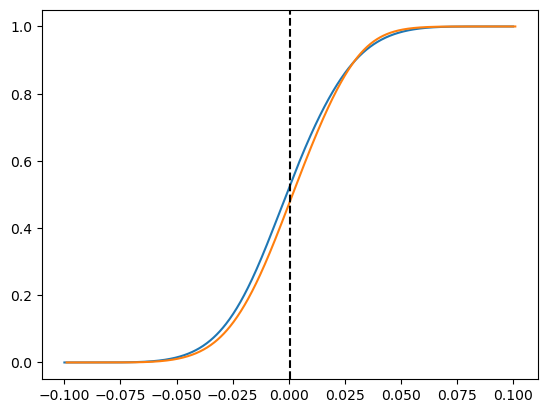

In [42]:
plt.plot(xgrid1,cdf1 );
plt.plot(xgrid2,cdf2 );
plt.axvline(test.statistic_location, c='black', ls='dashed' );

Records of the `ks_2samp` test:



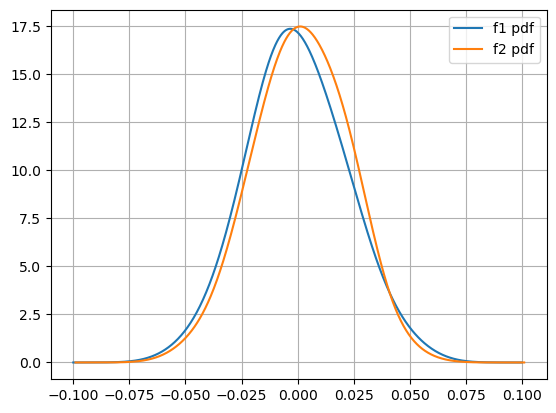

In [43]:


plt.plot(xgrid1,f1pdf,label= 'f1 pdf')
plt.plot(xgrid2,f2pdf,label= 'f2 pdf')
# astropy.visualization.hist(f1, bins= 'freedman', histtype= 'step' ,label = 'f1', density = True)
# astropy.visualization.hist(f2, bins= 'freedman', histtype= 'step' ,label = 'f2', density = True)
plt.legend()
plt.grid();